# 08b 최종 모델 테스트셋 평가

**TP 정의**: 고장 디스크의 **첫 번째 알람**이 `failure=1` 구간(D-1 ~ D-30) 내에서 발생 → TP  
> 07a 임계값 결정과 동일한 기준으로 공정하게 평가합니다.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 한글 폰트
for _fn in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if any(_fn.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _fn; break
plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트
_cwd = Path(os.getcwd())
ROOT = _cwd.parent if _cwd.name == "notebooks2" else _cwd
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config.final_eval_config as cfg
from src.eval_core import load_saved_ensemble

print("설정 로드 완료")
print(f"  MODEL_SAVE_DIR : {cfg.MODEL_SAVE_DIR}")
print(f"  TEST_PATH      : {cfg.TEST_PATH}")

설정 로드 완료
  MODEL_SAVE_DIR : C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  TEST_PATH      : C:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\test.parquet


In [2]:
print("모델 및 메타데이터 로드 중...")
artifacts     = load_saved_ensemble(cfg, require_threshold=True)
ensemble      = artifacts["ensemble"]
feature_cols  = artifacts["feature_cols"]
threshold_meta = artifacts["threshold_meta"]
BEST_T        = artifacts["threshold"]   # 0.4875 (0.5% FAR 운영점)

print(f"\n운영 임계값(0.5% FAR 기준): BEST_T = {BEST_T:.4f}")
print(f"특징 수: {len(feature_cols)}")

모델 및 메타데이터 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\feature_cols.json (386 bytes)
  [OK] best threshold metadata: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\best_threshold.json (1,586 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\feature_cols.json (17 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\best_threshold.json
  threshold: 0.487513
  threshold_source_val_calib: c:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_calib.parquet
  model: subset_00.pkl (297,156 bytes)
  model: subset_01.pk

In [3]:
print("테스트 데이터 로드 중...")
test_path = Path(cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
print(f"  rows={len(df_test):,}  failure_rows={df_test[cfg.TARGET_COL].sum():,}  "
      f"serials={df_test[cfg.SERIAL_COL].nunique():,}")

# 예측 캐시
cache_path = Path(getattr(cfg, "PREDICTIONS_DIR", cfg.MODEL_SAVE_DIR)) / f"{test_path.stem}_probs.npy"
if cache_path.exists():
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        print(f"캐시 크기 불일치 → 재추론")
        y_prob = None
    else:
        print(f"캐시 로드: {cache_path.name}")
else:
    y_prob = None

if y_prob is None:
    print("앙상블 추론 실행 중...")
    t0 = time.perf_counter()
    y_prob = ensemble.predict_proba(df_test, feature_cols, verbose=True)
    np.save(cache_path, y_prob)
    print(f"추론 완료 ({time.perf_counter()-t0:.1f}s), 캐시 저장: {cache_path.name}")

df_test["_prob"] = y_prob
print("완료")

테스트 데이터 로드 중...
  rows=15,373,460  failure_rows=34,473  serials=16,804
캐시 로드: test_probs.npy
완료


In [4]:
print("디스크 단위 그룹화 중...")
df_test["_base"] = df_test[cfg.SERIAL_COL].str.replace(r'_\d+$', '', regex=True)
df_test[cfg.DATE_COL] = pd.to_datetime(df_test[cfg.DATE_COL])
df_test = df_test.sort_values(["_base", cfg.DATE_COL])

disks = []
for base_sn, grp in df_test.groupby("_base", sort=False):
    disks.append({
        "base_serial" : base_sn,
        "is_failed"   : int(grp[cfg.TARGET_COL].max()),
        "probs"       : grp["_prob"].values,
        "failures"    : grp[cfg.TARGET_COL].values,
        "dates"       : grp[cfg.DATE_COL].values,
    })

n_failed = sum(d["is_failed"] for d in disks)
n_normal = len(disks) - n_failed
print(f"디스크: 총 {len(disks):,}개  |  고장 {n_failed:,}개  |  정상 {n_normal:,}개")

# 평가에 자주 쓸 부분집합
normal_disks = [d for d in disks if d["is_failed"] == 0]
failed_disks = [d for d in disks if d["is_failed"] == 1]
normal_max_probs = np.array([d["probs"].max() for d in normal_disks])

디스크 단위 그룹화 중...
디스크: 총 7,381개  |  고장 1,135개  |  정상 6,246개


In [5]:
def eval_operating_point(T: float) -> dict:
    """
    07a와 동일한 TP 정의:
      TP = 첫 번째 알람이 failure=1 행(D-1~D-30)에서 발생
      FN = 알람 없음 OR 첫 알람이 failure=0 행에서 발생
      FP = 정상 디스크에서 1회 이상 알람
    """
    fps = int(np.sum(normal_max_probs >= T))

    tps = 0
    tp_lead_times = []  # 첫 알람 → 마지막(failure=1 구간 끝) 까지 일수
    for d in failed_disks:
        alarm_idx = np.where(d["probs"] >= T)[0]
        if len(alarm_idx) > 0 and d["failures"][alarm_idx[0]] == 1:
            tps += 1
            # 리드타임: 첫 알람일 ~ 마지막 failure=1 행 날짜
            trigger_date = pd.Timestamp(d["dates"][alarm_idx[0]])
            last_fail_date = pd.Timestamp(d["dates"][d["failures"] == 1][-1])
            tp_lead_times.append((last_fail_date - trigger_date).days)

    fns = n_failed - tps
    prec = tps / (tps + fps) if (tps + fps) > 0 else 0.0
    return dict(
        threshold = T,
        tps       = tps,
        fps       = fps,
        fns       = fns,
        recall    = tps / n_failed,
        far       = fps / n_normal,
        precision = prec,
        lead_times= tp_lead_times,
    )

print("평가 함수 정의 완료 (07a 동일 TP 기준)")

평가 함수 정의 완료 (07a 동일 TP 기준)


In [6]:
op_points = threshold_meta.get("operating_points", [])

print()
print("=" * 68)
print("  테스트셋 최종 평가  (TP 기준: 첫 알람이 failure=1 구간에 있어야 함)")
print("=" * 68)
print(f"  {'threshold':<12}  {'Disk FAR':>10}  {'Disk Recall':>12}  {'Precision':>11}")
print("-" * 68)

results = {}
for op in op_points:
    T = op["threshold"]
    r = eval_operating_point(T)
    results[T] = r
    print(f"  {T:<12.4f}  {r['far']*100:>9.2f}%  {r['recall']*100:>11.2f}%  {r['precision']*100:>10.2f}%")

print("=" * 68)
print()
print("[참고: val_calib 기준 (07a에서 결정된 값)]")
print(f"  {'threshold':<12}  {'Disk FAR':>10}  {'Disk Recall':>12}  {'Precision':>11}")
print("-" * 68)
for op in op_points:
    T   = op["threshold"]
    far = op["disk_far"]
    rec = op["disk_recall"]
    pre = op["precision"]
    print(f"  {T:<12.4f}  {far*100:>9.2f}%  {rec*100:>11.2f}%  {pre*100:>10.2f}%")
print("=" * 68)

# BEST_T 운영점 결과 저장 (하단 시각화용)
best_result = results.get(BEST_T, eval_operating_point(BEST_T))


  테스트셋 최종 평가  (TP 기준: 첫 알람이 failure=1 구간에 있어야 함)
  threshold       Disk FAR   Disk Recall    Precision
--------------------------------------------------------------------
  0.6354             0.13%        14.36%       95.32%
  0.4875             0.82%        25.11%       84.82%
  0.4106             1.17%        28.28%       81.47%
  0.2937             2.35%        31.63%       70.95%

[참고: val_calib 기준 (07a에서 결정된 값)]
  threshold       Disk FAR   Disk Recall    Precision
--------------------------------------------------------------------
  0.6354             0.10%        14.94%       96.59%
  0.4875             0.48%        24.43%       90.26%
  0.4106             0.99%        27.42%       83.42%
  0.2937             1.99%        31.46%       74.27%


T=0.4875 기준 탐지된 고장 디스크: 285개
  리드타임  평균: 5.6일  중앙값: 3.0일  최소: 0일  최대: 30일


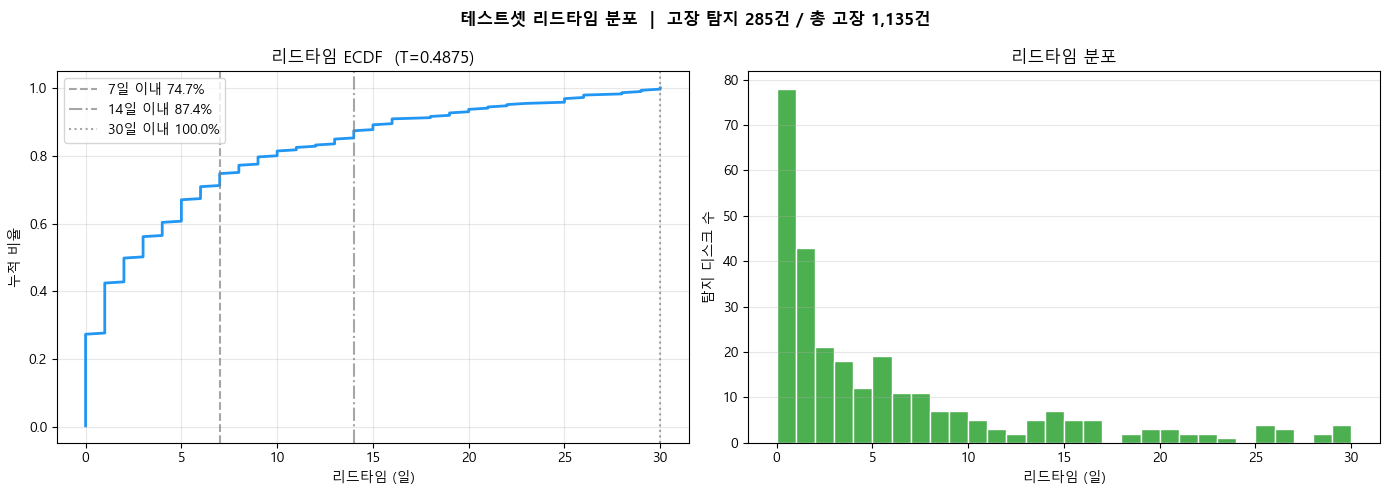

저장: 08b_lead_time_ecdf.png


In [7]:
lead_times_arr = np.array(best_result["lead_times"])
print(f"T={BEST_T:.4f} 기준 탐지된 고장 디스크: {len(lead_times_arr):,}개")
print(f"  리드타임  평균: {lead_times_arr.mean():.1f}일  "
      f"중앙값: {np.median(lead_times_arr):.1f}일  "
      f"최소: {lead_times_arr.min()}일  최대: {lead_times_arr.max()}일")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ECDF
sorted_lt = np.sort(lead_times_arr)
ecdf_y    = np.arange(1, len(sorted_lt) + 1) / len(sorted_lt)
axes[0].plot(sorted_lt, ecdf_y, lw=2, color="#2196F3")
for days, ls in [(7, "--"), (14, "-."), (30, ":")]:
    pct = (lead_times_arr <= days).mean() * 100
    axes[0].axvline(days, color="gray", linestyle=ls, alpha=0.7,
                    label=f"{days}일 이내 {pct:.1f}%")
axes[0].set_xlabel("리드타임 (일)"); axes[0].set_ylabel("누적 비율")
axes[0].set_title(f"리드타임 ECDF  (T={BEST_T:.4f})")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 히스토그램
axes[1].hist(lead_times_arr, bins=30, color="#4CAF50", edgecolor="white")
axes[1].set_xlabel("리드타임 (일)"); axes[1].set_ylabel("탐지 디스크 수")
axes[1].set_title("리드타임 분포")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(f"테스트셋 리드타임 분포  |  고장 탐지 {len(lead_times_arr):,}건 / "
             f"총 고장 {n_failed:,}건", fontsize=12, fontweight="bold")
plt.tight_layout()
os.makedirs("results/08b_/plots", exist_ok=True)
plt.savefig("notebooks2/reports2/plots/08b_lead_time_ecdf.png", dpi=150)
plt.show()
print("저장: 08b_lead_time_ecdf.png")

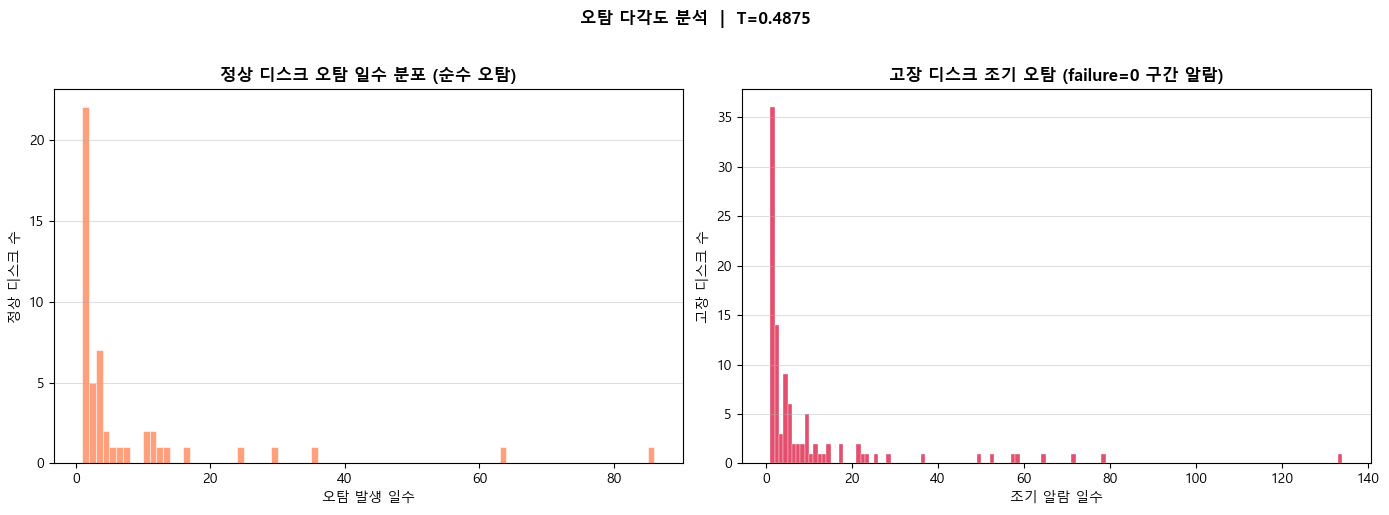

정상 디스크 중 오탐 발생: 51개 / 6,246개
고장 디스크 중 조기 오탐: 103개 / 1,135개
저장: 08b_false_alarm_analysis.png


In [8]:
T = BEST_T

# 정상 디스크 순수 오탐 일수
normal_fa_days = []
for d in normal_disks:
    n_alarms = int(np.sum(d["probs"] >= T))
    if n_alarms > 0:
        normal_fa_days.append(n_alarms)
normal_fa_days = np.array(normal_fa_days)

# 고장 디스크 조기 오탐 (failure=0 구간에서의 알람 수)
early_fa_days = []
for d in failed_disks:
    y_pred = (d["probs"] >= T).astype(int)
    early = int(np.sum(y_pred[d["failures"] == 0]))
    if early > 0:
        early_fa_days.append(early)
early_fa_days = np.array(early_fa_days)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#ffffff")

if len(normal_fa_days) > 0:
    sns.histplot(normal_fa_days, binwidth=1, kde=False, color="coral",
                 edgecolor="white", ax=ax1)
ax1.set_title("정상 디스크 오탐 일수 분포 (순수 오탐)", fontweight="bold")
ax1.set_xlabel("오탐 발생 일수"); ax1.set_ylabel("정상 디스크 수"); ax1.grid(axis="y", alpha=0.4)

if len(early_fa_days) > 0:
    sns.histplot(early_fa_days, binwidth=1, kde=False, color="crimson",
                 edgecolor="white", ax=ax2)
ax2.set_title("고장 디스크 조기 오탐 (failure=0 구간 알람)", fontweight="bold")
ax2.set_xlabel("조기 알람 일수"); ax2.set_ylabel("고장 디스크 수"); ax2.grid(axis="y", alpha=0.4)

plt.suptitle(f"오탐 다각도 분석  |  T={T:.4f}", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("notebooks2/reports2/plots/08b_false_alarm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"정상 디스크 중 오탐 발생: {len(normal_fa_days):,}개 / {n_normal:,}개")
print(f"고장 디스크 중 조기 오탐: {len(early_fa_days):,}개 / {n_failed:,}개")
print("저장: 08b_false_alarm_analysis.png")

In [9]:
import pandas as pd

rows = []
for op in op_points:
    T = op["threshold"]
    r = results.get(T, eval_operating_point(T))
    rows.append({
        "threshold"    : T,
        "far_cap"      : op["far_cap"],
        "test_far_%"   : round(r["far"] * 100, 4),
        "test_recall_%" : round(r["recall"] * 100, 4),
        "test_precision_%": round(r["precision"] * 100, 4),
        "test_tps"     : r["tps"],
        "test_fps"     : r["fps"],
        "test_fns"     : r["fns"],
        "calib_far_%"  : round(op["disk_far"] * 100, 4),
        "calib_recall_%": round(op["disk_recall"] * 100, 4),
        "calib_precision_%": round(op["precision"] * 100, 4),
    })

df_report = pd.DataFrame(rows)
os.makedirs("results/08b_", exist_ok=True)
df_report.to_csv("notebooks2/reports2/08b_test_evaluation.csv",
                 index=False, encoding="utf-8-sig")

print("저장: notebooks2/reports2/08b_test_evaluation.csv")
print()
print(df_report.to_string(index=False))

저장: notebooks2/reports2/08b_test_evaluation.csv

 threshold  far_cap  test_far_%  test_recall_%  test_precision_%  test_tps  test_fps  test_fns  calib_far_%  calib_recall_%  calib_precision_%
  0.635364    0.001      0.1281        14.3612           95.3216       163         8       972       0.0961         14.9385            96.5909
  0.487513    0.005      0.8165        25.1101           84.8214       285        51       850       0.4803         24.4288            90.2597
  0.410590    0.010      1.1687        28.2819           81.4721       321        73       814       0.9926         27.4165            83.4225
  0.293707    0.020      2.3535        31.6300           70.9486       359       147       776       1.9853         31.4587            74.2739
